# Import libs and read data

In [1]:

import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
import os, json

from Strong_hierarchical_lasso.SHIM import * # our library


base_path = "../../Data/Data_Deoxyfluorination"
filename_Xtrain = "X_train_deoxy.csv"
filename_Xtest = "X_test_deoxy.csv"
filename_ytrain = "y_train_deoxy.csv"
filename_ytest = "y_test_deoxy.csv"
filename_names_main="main_names.json"

X_train = pd.read_csv(os.path.join(base_path,filename_Xtrain)).to_numpy()
X_test = pd.read_csv(os.path.join(base_path,filename_Xtest)).to_numpy()
y_train = pd.read_csv(os.path.join(base_path,filename_ytrain)).to_numpy().ravel()  
y_test = pd.read_csv(os.path.join(base_path,filename_ytest)).to_numpy().ravel()
with open(os.path.join(base_path,filename_names_main), "r") as file:
    main_names = json.load(file)






# Train with AIC params on full data and estimate all coefficients

 Start iteration: 1;
Updated intercept
Updated beta
Updated gamma
Updated delta
 Start iteration: 2;
Updated intercept
Updated beta
Updated gamma
Updated delta
 Start iteration: 3;
Updated intercept
Updated beta
Updated gamma
Updated delta
 Start iteration: 4;
Updated intercept
Updated beta
Updated gamma
Updated delta
 Start iteration: 5;
Updated intercept
Updated beta
Updated gamma
Updated delta
 Start iteration: 6;
Updated intercept
Updated beta
Updated gamma
Updated delta
 Start iteration: 7;
Updated intercept
Updated beta
Updated gamma
Updated delta
 Start iteration: 8;
Updated intercept
Updated beta
Updated gamma
Updated delta
The model has converged.
R² score: 0.8762839819213413


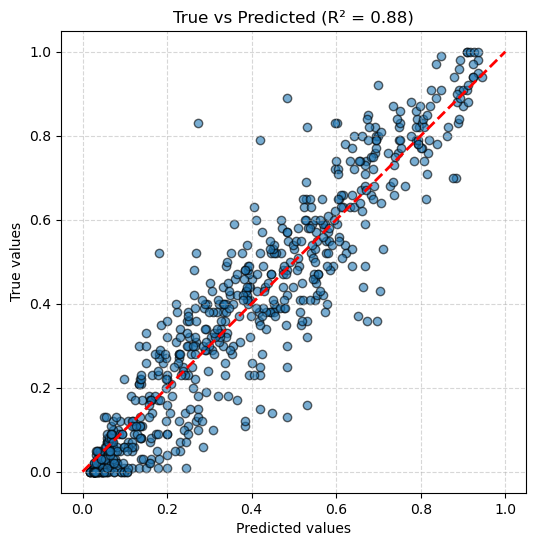

0.8762839819213413

In [2]:

#get X_all
X_all = np.vstack([X_train, X_test])   

# Combine target vectors
y_all = np.concatenate([y_train, y_test])  



#levels
l1, l2, l3= 31, 3, 4 

levels_list=[l1,l2,l3]
lambdas_list=[5e-4,1e-3,1e-3] ## AIC selected

shim = SHIM(X=X_all,
            y=y_all,
            init_list=None,
            levels_list=levels_list,
            lambdas_list=list(lambdas_list),
            max_iter=10,
            use_init_main = True,
            use_init_main_w= True,
            w_list=None, response='cb'
        )

shim_fitted = shim.fit_model()
shim_fitted.R2_score(X_all, y_all, plot=True)
#print(shim_fitted.model.beta_hat)
#print(shim_fitted.model.gamma_hat)
#print(shim_fitted.model.delta_hat)


# Recover the coefficicents with identifiability conditions and save them


In [3]:
beta_all_shim=shim_fitted.model.beta_all
intercept_all=shim_fitted.model.intercept

print(f"Number of non-zeros in fitted coefficients  is: {sum(beta_all_shim!=0)+1} out of {len(beta_all_shim)+1} coefficients.")

coefs_all = np.concatenate(([intercept_all], beta_all_shim))
lambda_beta, lambda_gamma, lambda_delta=lambdas_list

recovered_coefs=recover_coefs_with_names(main_names=main_names, beta= beta_all_shim, intercept=intercept_all, levels=levels_list)
print(f"Number of non-zeros in recovered coefficients  is: {sum(recovered_coefs["Values"].values!=0)+1} out of {len(recovered_coefs["Values"].values)} coefficients.")

recovered_coefs.to_excel("Final_coefficients_Deoxy.xlsx")
print("The final coefficients are saved in Analysis_Deoxyfluorination.")


Number of non-zeros in fitted coefficients  is: 121 out of 640 coefficients.
Number of non-zeros in recovered coefficients  is: 203 out of 990 coefficients.
The final coefficients are saved in Analysis_Deoxyfluorination.
